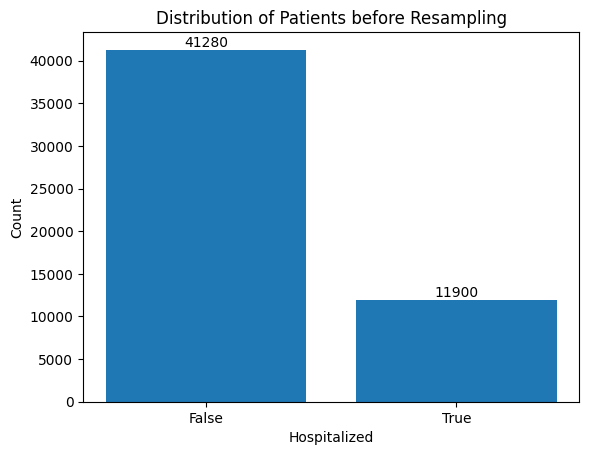

,pre_test,age_group_18 to 49 years,age_group_50 to 64 years,age_group_65+ years,sex_Male,race_Asian,race_Black,race_Multiple/Other,race_Native Hawaiian/Other Pacific Islander,race_White,ethnicity_Non-Hispanic/Latino,underlying_conditions_yn_Yes
0,0,True,False,False,False,False,False,False,False,True,True,True
1,0,False,False,True,True,False,False,False,False,True,True,True
2,0,True,False,False,True,False,False,False,False,True,False,True
3,0,True,False,False,False,False,True,False,False,False,True,True
4,0,True,False,False,False,False,False,False,False,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...
53175,0,True,False,False,False,False,True,False,False,False,True,True
53176,1,False,False,True,True,False,False,False,False,True,True,True
53177,0,True,False,False,True,False,False,False,False,True,True,True
53178,0,True,False,False,False,False,True,False,False,False,True,True


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler

df = pd.read_csv("/Users/Nico/Desktop/DS5110/Project/Code/PREPROCESSED_NO_MISSING_UKNOWN.csv")
df_cleaned = df.drop(columns=['Unnamed: 0','state_fips_code','county_fips_code'])
df_extracleaned = df_cleaned.drop(columns=['res_state','res_county','process','case_month','icu_yn','current_status','death_yn','case_positive_specimen_interval','case_onset_interval'])

X = df_extracleaned.drop(columns='hosp_yn')
y = df_extracleaned['hosp_yn']
cols = df.columns

le = LabelEncoder()
y_encoded = le.fit_transform(y)
X_dummies = pd.get_dummies(X,drop_first=True)

vals, counts = np.unique(y_encoded,return_counts=True)
fig, ax = plt.subplots()
bars = ax.bar(vals,counts)
ax.bar_label(bars)
ax.set_title('Distribution of Patients before Resampling')
ax.set_xlabel('Hospitalized')
ax.set_ylabel('Count')
plt.xticks([0,1],["False","True"])
plt.show()

X_dummies

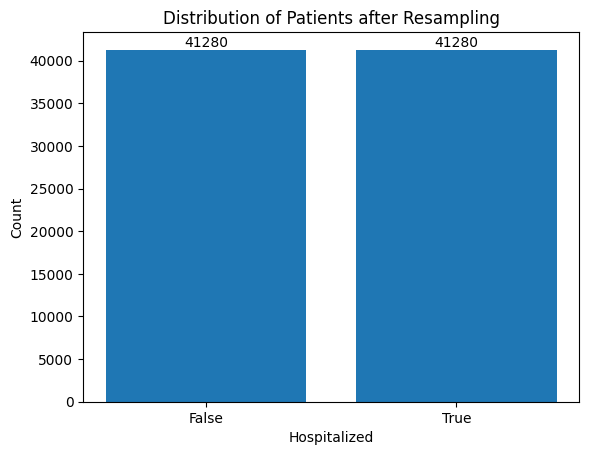

In [3]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42, k_neighbors=5)
X_resampled, y_resampled = smote.fit_resample(X_dummies,y_encoded)

vals, counts = np.unique(y_resampled, return_counts=True)
fig, ax = plt.subplots()
bars = ax.bar(vals,counts)
ax.bar_label(bars)
ax.set_title('Distribution of Patients after Resampling')
ax.set_xlabel('Hospitalized')
ax.set_ylabel('Count')
plt.xticks([0,1],["False","True"])
plt.show()

In [4]:
from sklearn.model_selection import train_test_split, cross_val_score
X_train_val, X_test, y_train_val, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)
X_train_val

,pre_test,age_group_18 to 49 years,age_group_50 to 64 years,age_group_65+ years,sex_Male,race_Asian,race_Black,race_Multiple/Other,race_Native Hawaiian/Other Pacific Islander,race_White,ethnicity_Non-Hispanic/Latino,underlying_conditions_yn_Yes
73306,0,False,False,True,False,False,False,False,False,True,True,True
80625,1,False,False,True,False,False,False,False,False,True,True,True
48123,1,True,False,False,False,False,False,False,False,True,True,True
8153,1,False,False,False,True,False,False,False,False,True,False,True
69588,0,False,False,True,True,False,False,False,False,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...
6265,1,True,False,False,False,False,False,False,False,True,True,True
54886,0,False,False,True,True,False,False,False,False,True,True,True
76820,1,False,False,True,False,False,False,False,False,True,True,True
860,0,True,False,False,False,False,False,False,False,True,True,True


In [5]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV,KFold

params = {
    'max_depth': list(range(2,11)),
    'n_estimators': list(range(3,19)),
    'learning_rate': np.linspace(0.05,1.0,20)
}

cv = KFold(n_splits=4,shuffle=True,random_state=42)
grid_search = GridSearchCV(
    estimator = XGBClassifier(random_state = 42),
    param_grid = params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
)

grid_search.fit(X_train_val, y_train_val)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': array([0.05, ..., 0.95, 1. ]), 'max_depth': [2, 3, ...], 'n_estimators': [3, 4, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate i

In [6]:
import pandas as pd
results = pd.DataFrame(grid_search.cv_results_)
cols = [
    'param_n_estimators',
    'param_max_depth',
    'mean_test_score',
    'std_test_score',
    'rank_test_score',
    'mean_fit_time'
]
results.sort_values('rank_test_score').head(10)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_learning_rate,param_max_depth,param_n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
2509,0.073443,0.003534,0.006790,0.000931,0.9,5,16,"{'learning_rate': 0.9, 'max_depth': 5, 'n_esti...",0.681378,0.685541,0.675095,0.682414,0.678477,0.680581,0.003553,1
2503,0.058475,0.001900,0.004940,0.000399,0.9,5,10,"{'learning_rate': 0.9, 'max_depth': 5, 'n_esti...",0.681453,0.685541,0.675473,0.681732,0.678553,0.680550,0.003373,2
2783,0.068125,0.004536,0.004947,0.000274,1.0,4,18,"{'learning_rate': 1.0, 'max_depth': 4, 'n_esti...",0.681075,0.685541,0.675322,0.682414,0.678325,0.680535,0.003491,3
2502,0.054423,0.002476,0.004949,0.000300,0.9,5,9,"{'learning_rate': 0.9, 'max_depth': 5, 'n_esti...",0.681151,0.685768,0.675473,0.681732,0.678553,0.680535,0.003428,4
2504,0.061601,0.001624,0.005447,0.000302,0.9,5,11,"{'learning_rate': 0.9, 'max_depth': 5, 'n_esti...",0.681453,0.685541,0.675473,0.681884,0.678325,0.680535,0.003413,5
2782,0.069704,0.002300,0.006448,0.001121,1.0,4,17,"{'learning_rate': 1.0, 'max_depth': 4, 'n_esti...",0.681075,0.685541,0.675246,0.682414,0.678325,0.680520,0.003514,6
2781,0.067034,0.001096,0.005273,0.000427,1.0,4,16,"{'learning_rate': 1.0, 'max_depth': 4, 'n_esti...",0.681075,0.685541,0.675246,0.682338,0.678325,0.680505,0.003506,7
2765,0.061417,0.000431,0.004928,0.000391,1.0,3,16,"{'learning_rate': 1.0, 'max_depth': 3, 'n_esti...",0.680848,0.685844,0.675170,0.682111,0.678553,0.680505,0.003563,7
2766,0.062920,0.000739,0.005331,0.000365,1.0,3,17,"{'learning_rate': 1.0, 'max_depth': 3, 'n_esti...",0.680848,0.685844,0.675170,0.682111,0.678553,0.680505,0.003563,7
2824,0.061744,0.002974,0.005601,0.000859,1.0,7,11,"{'learning_rate': 1.0, 'max_depth': 7, 'n_esti...",0.680772,0.685617,0.675170,0.682414,0.678401,0.680475,0.003542,10


Accuracy: 0.6858042635658915

Classification Report:
              precision    recall  f1-score   support

          No       0.70      0.64      0.67      8117
         Yes       0.68      0.73      0.70      8395

    accuracy                           0.69     16512
   macro avg       0.69      0.69      0.68     16512
weighted avg       0.69      0.69      0.69     16512


Confusion Matrix:
Sensitivity: 0.7317450863609292 
Specificity/Recall: 0.6382900086238759 
Precision 0.6766163674413481


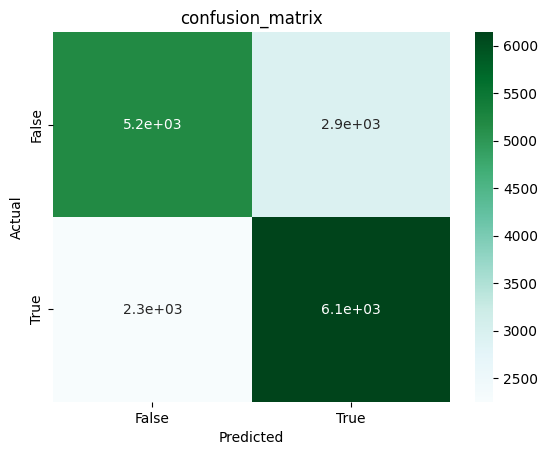

In [7]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

y_pred = grid_search.best_estimator_.predict(X_test)

print("Accuracy:", grid_search.best_estimator_.score(X_test, y_test))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

print("\nConfusion Matrix:")
plt.figure()
# cmap = sns.color_palette(['#CAD733','#00BF00','#077187','#054ED9','#074F57','#EF3E36','#C056A5'], as_cmap=True)
cmap = sns.color_palette('BuGn', as_cmap=True)
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap=cmap)
plt.title('confusion_matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks([0.5,1.5],["False","True"])
plt.yticks([0.5,1.5],["False","True"])

conf = confusion_matrix(y_test,y_pred)
tn = conf[0,0]
fn = conf[1,0]
fp = conf[0,1]
tp = conf[1,1]

sensitivity = tp/(tp+fn)
specificity = tn/(tn+fp)
precision = tp/(tp+fp)
print('Sensitivity:',sensitivity,'\nSpecificity/Recall:',specificity,'\nPrecision',precision)

                                    Feature  Importance
                        age_group_65+ years    0.692569
                   age_group_50 to 64 years    0.152227
                                   pre_test    0.040461
race_Native Hawaiian/Other Pacific Islander    0.028165
                                 race_Black    0.024099
              ethnicity_Non-Hispanic/Latino    0.012193
                                   sex_Male    0.012189
                                 race_White    0.011352
                   age_group_18 to 49 years    0.010050
                                 race_Asian    0.006930
               underlying_conditions_yn_Yes    0.006927
                        race_Multiple/Other    0.002839


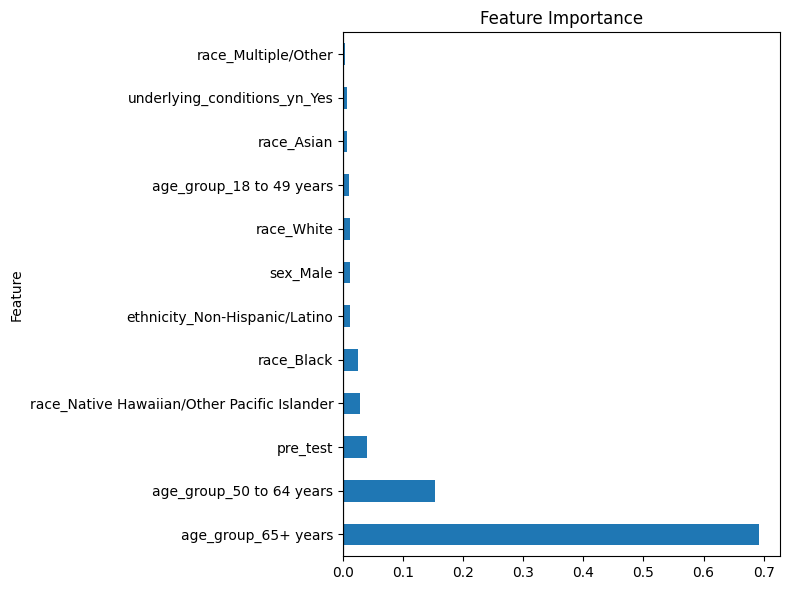

In [8]:
coef_df = pd.DataFrame({
    'Feature': X_dummies.columns,
    'Importance': grid_search.best_estimator_.feature_importances_
}).sort_values('Importance', ascending=False)

print(coef_df.to_string(index=False))

# Feature coefficients plot
coef_df.plot(kind='barh', x='Feature', y='Importance', figsize=(8, 6), legend=False)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Feature Importance')
plt.tight_layout()
plt.show()

Note: Claude AI was used to support the postprocessing of the model after fitting the model to the data